### Intro to Python Programming
- Prof Joanna Bieri
- Office: Duke 209

### Day 19 - GeoPandas - mapping spatial data

We will continue to work on interacting with data using pandas and we will start building in layers of things we have done before: loops, functions, user inputs.

Just to give use experience in some fun new packages, today we are going to focus on GeoPandas - this package makes it easy to plot spatial data while still having all the feel of the Pandas that we are use to.

### Install Extra Packages

You might need to install these extra packages to get this code to run. If you have errors you can uncomment and run each of the installs until the errors are gone.

In [1]:
#!pip install geopandas
#!pip install mapclassify
#!pip install cartopy
#!pip install -U numba
#!pip install numpy==1.23.1

In [2]:
# Our good old fashioned packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Geopandas with the nickname gpd
import geopandas as gpd

# Packages that help us with map projections.
import cartopy
import cartopy.crs as ccrs

/home/bellajagu/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/bellajagu/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


### Data

Our data today is about different types of power plants in Europe. The class lecture today follows this great geopandas tutorial: https://fneum.github.io/data-science-for-esm/04-workshop-geopandas.html

We are just going to scratch the surface of geopandas, so if you are interested in spatial data science check out some other great tutorials.

#### Read this in as a regular pandas file

In [3]:
website = 'https://joannabieri.com/python/'
file_name = website + "powerplants.csv"
DF = pd.read_csv(file_name, index_col=0)

### Your frst job with any data is to look at the data - what is in this data set?

In [4]:
DF.head(5)

,Name,Fueltype,Technology,Set,Country,Capacity,Efficiency,DateIn,DateRetrofit,DateOut,lat,lon,Duration,Volume_Mm3,DamHeight_m,StorageCapacity_MWh,EIC,projectID
id,,,,,,,,,,,,,,,,,,
0,Borssele,Hard Coal,Steam Turbine,PP,Netherlands,485.0,NaN,1973.0,NaN,2034.0,51.4332,3.7160,NaN,0.0,0.0,0.0,{'49W000000000054X'},"{'BEYONDCOAL': {'BEYOND-NL-2'}, 'ENTSOE': {'49..."
1,Sainte Croix,Hydro,Reservoir,Store,France,132.3,NaN,1974.0,NaN,NaN,43.7375,6.1343,NaN,0.0,0.0,0.0,{'17W100P100P0297X'},"{'ENTSOE': {'17W100P100P0297X'}, 'GEM': {'G601..."
2,Pied De Borne,Hydro,Reservoir,Store,France,109.4,NaN,1965.0,NaN,NaN,44.4788,3.9858,NaN,0.0,0.0,0.0,{'17W100P100P0289W'},"{'ENTSOE': {'17W100P100P0289W'}, 'GEM': {'G601..."
3,Pouget,Hydro,Reservoir,Store,France,446.9,NaN,1951.0,NaN,NaN,44.0597,2.7701,1.573034,0.0,0.0,0.0,{'17W100P100P0290A'},"{'ENTSOE': {'17W100P100P0290A'}, 'GEM': {'G601..."
4,Pragneres,Hydro,Reservoir,Store,France,189.2,NaN,1953.0,NaN,NaN,42.8205,0.0102,NaN,0.0,0.0,0.0,{'17W100P100P02918'},"{'ENTSOE': {'17W100P100P02918'}, 'GEM': {'G601..."


In [4]:
# Column Names
DF.keys()

Index(['Name', 'Fueltype', 'Technology', 'Set', 'Country', 'Capacity',
       'Efficiency', 'DateIn', 'DateRetrofit', 'DateOut', 'lat', 'lon',
       'Duration', 'Volume_Mm3', 'DamHeight_m', 'StorageCapacity_MWh', 'EIC',
       'projectID'],
      dtype='object')

In [5]:
# Information about the data in each column
DF.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6374 entries, 0 to 6616
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Name                 6374 non-null   object 
 1   Fueltype             6374 non-null   object 
 2   Technology           5702 non-null   object 
 3   Set                  6374 non-null   object 
 4   Country              6374 non-null   object 
 5   Capacity             6374 non-null   float64
 6   Efficiency           542 non-null    float64
 7   DateIn               4450 non-null   float64
 8   DateRetrofit         1871 non-null   float64
 9   DateOut              349 non-null    float64
 10  lat                  6374 non-null   float64
 11  lon                  6374 non-null   float64
 12  Duration             452 non-null    float64
 13  Volume_Mm3           6374 non-null   float64
 14  DamHeight_m          6374 non-null   float64
 15  StorageCapacity_MWh  6374 non-null   float6

In [6]:
# Statistical data
DF.describe()

,Capacity,Efficiency,DateIn,DateRetrofit,DateOut,lat,lon,Duration,Volume_Mm3,DamHeight_m,StorageCapacity_MWh
count,6374.000000,542.000000,4450.000000,1871.000000,349.000000,6374.000000,6374.000000,452.000000,6374.000000,6374.000000,6374.000000
mean,141.550081,0.480459,1982.047416,1984.920363,2020.418338,48.915773,7.879248,1201.563456,7.128439,4.872220,410.191716
std,391.501198,0.179431,88.218795,24.935544,9.537422,6.850656,9.083968,1603.428940,138.334742,47.251297,9267.942691
min,0.000000,0.140228,0.000000,1899.000000,1996.000000,32.742000,-17.055700,0.007907,0.000000,0.000000,0.000000
25%,9.800000,0.356400,1966.000000,1967.000000,2015.000000,43.472075,0.740450,34.009337,0.000000,0.000000,0.000000
50%,26.000000,0.385710,1994.000000,1991.000000,2019.000000,48.133707,8.545323,641.151139,0.000000,0.000000,0.000000
75%,86.000000,0.580829,2008.000000,2005.000000,2023.000000,52.420000,13.098021,1839.818750,0.000000,0.000000,0.000000
max,6000.000000,0.917460,2023.000000,2020.000000,2051.000000,70.689366,39.261917,16840.000000,9500.000000,1800.000000,421000.000000


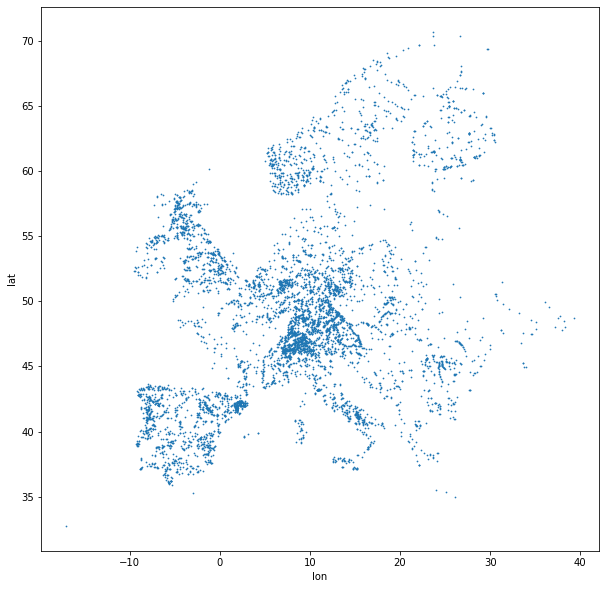

In [8]:
# Put a point at each latitude and longidude locaition
plt.figure(figsize=(10,10))
plt.scatter(DF['lon'],DF['lat'],s=.5)
plt.xlabel('lon')
plt.ylabel('lat')
plt.show()

### Pandas lacks the ability to really deal with spatial data

### Geopandas will let us:

- plot the data over the top of boundary maps
- consider different map projections
- join different data sets together into one map.
- and much more!

## Convert the Pandas DF to a GeoPandas DF

A GeoPandas DataFrame should contain both the raw data in the columns along with geometry data. The geometry data can take lots of forms:

- points - Lat and Long
- polygons - Spatial regions build out of polygons
- etc.

An important part of a map is the Coordinate Reference System (crs). 

To make a map you have to get information about a 3-d object (surface of the earth) and project it onto a flat surface (the map). We are basically transforming the sphere of the Earth onto a plane. There are lots of ways to do this and lots of math behind this. We will show a few examples here.

A coordinate reference system (crs) tells us how the 2-d data relates to real places on the earth.

In [9]:
geometry = gpd.points_from_xy(DF["lon"], DF["lat"])
gDF = gpd.GeoDataFrame(DF, geometry=geometry, crs=4326)

### We have now added the needed geometric data to the DataFrame()

In [10]:
gDF.head(5)

,Name,Fueltype,Technology,Set,Country,Capacity,Efficiency,DateIn,DateRetrofit,DateOut,lat,lon,Duration,Volume_Mm3,DamHeight_m,StorageCapacity_MWh,EIC,projectID,geometry
id,,,,,,,,,,,,,,,,,,,
0,Borssele,Hard Coal,Steam Turbine,PP,Netherlands,485.0,NaN,1973.0,NaN,2034.0,51.4332,3.7160,NaN,0.0,0.0,0.0,{'49W000000000054X'},"{'BEYONDCOAL': {'BEYOND-NL-2'}, 'ENTSOE': {'49...",POINT (3.71600 51.43320)
1,Sainte Croix,Hydro,Reservoir,Store,France,132.3,NaN,1974.0,NaN,NaN,43.7375,6.1343,NaN,0.0,0.0,0.0,{'17W100P100P0297X'},"{'ENTSOE': {'17W100P100P0297X'}, 'GEM': {'G601...",POINT (6.13430 43.73750)
2,Pied De Borne,Hydro,Reservoir,Store,France,109.4,NaN,1965.0,NaN,NaN,44.4788,3.9858,NaN,0.0,0.0,0.0,{'17W100P100P0289W'},"{'ENTSOE': {'17W100P100P0289W'}, 'GEM': {'G601...",POINT (3.98580 44.47880)
3,Pouget,Hydro,Reservoir,Store,France,446.9,NaN,1951.0,NaN,NaN,44.0597,2.7701,1.573034,0.0,0.0,0.0,{'17W100P100P0290A'},"{'ENTSOE': {'17W100P100P0290A'}, 'GEM': {'G601...",POINT (2.77010 44.05970)
4,Pragneres,Hydro,Reservoir,Store,France,189.2,NaN,1953.0,NaN,NaN,42.8205,0.0102,NaN,0.0,0.0,0.0,{'17W100P100P02918'},"{'ENTSOE': {'17W100P100P02918'}, 'GEM': {'G601...",POINT (0.01020 42.82050)


### Make a plot of the data

We can use the .plot() function on the dataframe to plot all sorts of things. Below we will plot the locatoins of the different fuel types, but make the marker size set by the capacity of the power plant.

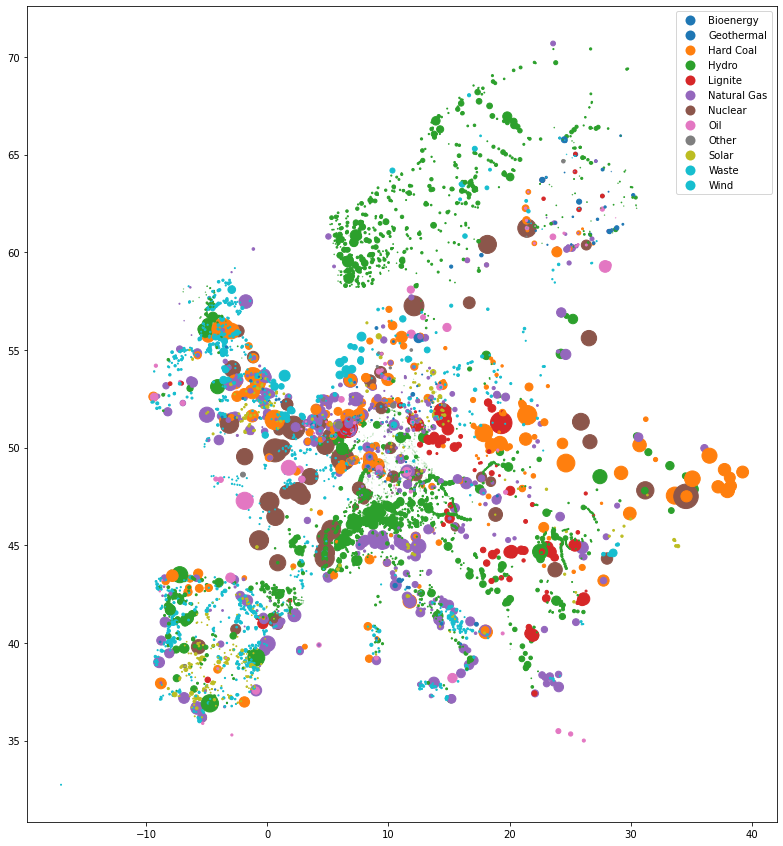

In [13]:
gDF.plot(column='Fueltype',
         figsize=(15,15),
         markersize=gDF['Capacity']/10,
        legend=True)

plt.show()

### Explore the map

The .explore() function lets you look at an interactive map of the data.

In [14]:
gDF.explore(column='Fueltype')

### Practice 1

1. Make a plot of the Technology types with marker size set by capacity
2. Explore a map of Technology types

In [ ]:
# Your code here



In [ ]:
# Your Code Here



### Extra Pandas Practice:

1. Sort the data by the storage capacity decending
2. Write a loop that prints out the differnt unique Technology types
3. Write a loop the prints out the differrnt unique Countries

In [ ]:
# Your code here


In [ ]:
# Your code here


In [ ]:
# Your code here


### Practice 2

1. Make a plot of the FuelType for just one country with marker size set by capacity.
2. Write a function that takes as an input a country name and creates a plot for that country or says the country is not found in the data

In [ ]:
# Your code here


In [ ]:
# Your code here


In [ ]:
# Call your function here


## Projections are important

Depending on how you decide to project your 3d sphere onto the 2d plane, your map could look very different!

Here is a webiste where you can find a list of projections available in the cartopy package:

https://scitools.org.uk/cartopy/docs/latest/reference/projections.html#cartopy-projections

### World map with the Plate Carree projection

Equidistant cylindrical projection.

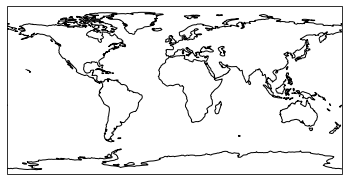

In [15]:
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

### World map with the Albers Equal Area projection

Equal area projections are important if you are measuring or comparing land area!

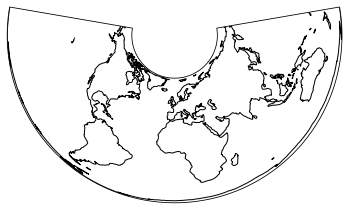

In [16]:
ax = plt.axes(projection=ccrs.AlbersEqualArea())
ax.coastlines()

### World map with the Molweide projection

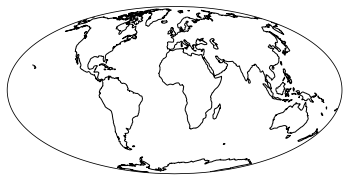

In [17]:
ax = plt.axes(projection=ccrs.Mollweide())
ax.coastlines()

### We will start by using the Plate Carree projection

#### Add Coastlines

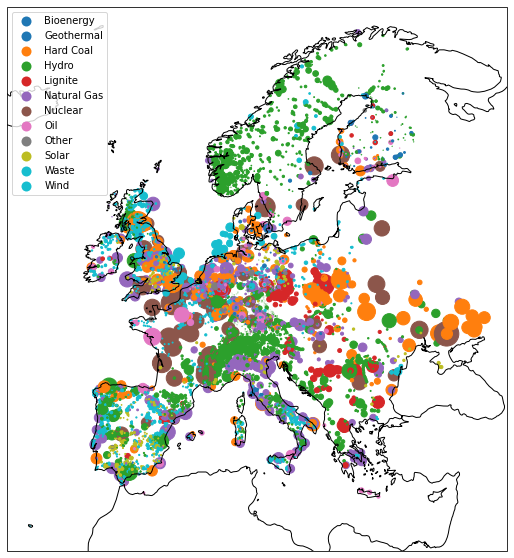

In [19]:
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

gDF.plot(ax=ax,
         column='Fueltype',
         markersize=gDF['Capacity']/10,
        legend=True)
ax.coastlines()

plt.show()

#### Add country borders

/home/bellajagu/.local/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/bellajagu/.local/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


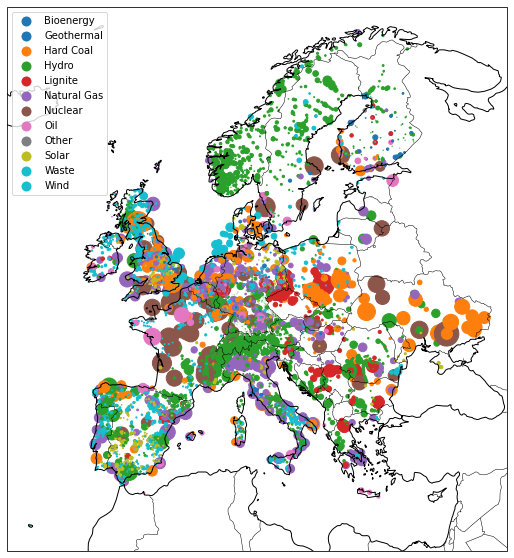

In [20]:
ax.add_feature(cartopy.feature.BORDERS, color="black", linewidth=0.5)
fig

#### Make the ocean blue - azure

/home/bellajagu/.local/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/bellajagu/.local/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


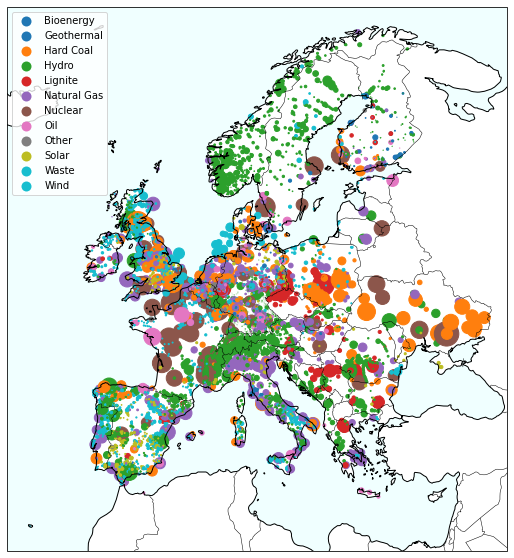

In [21]:
ax.add_feature(cartopy.feature.OCEAN, color="azure")
fig

#### Make the land yellow - cornsilk

/home/bellajagu/.local/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/bellajagu/.local/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


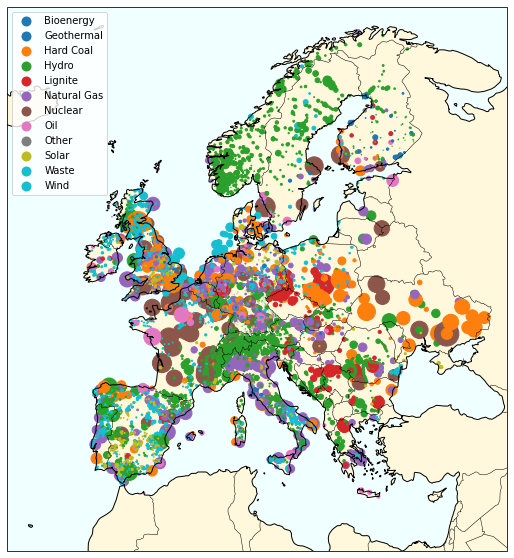

In [22]:
ax.add_feature(cartopy.feature.LAND, color="cornsilk")
fig

### Practice 3

Play around with the map code below. See how you can chagne what is there. Colors, Marker sizes, add a legend, chage the data plotted, etc.

/home/bellajagu/.local/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/bellajagu/.local/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


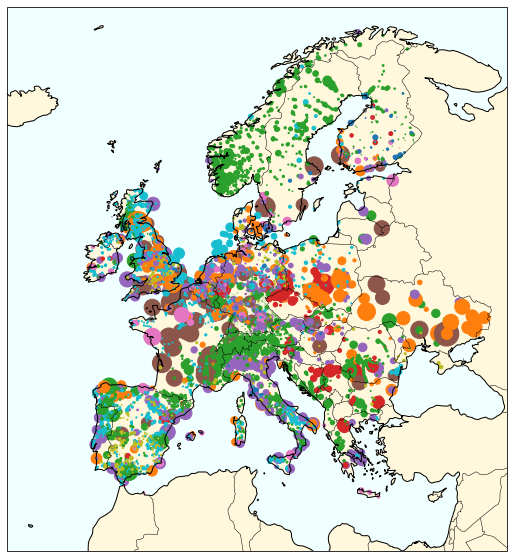

In [23]:
# Change the code here:

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

gDF.plot(ax=ax,
         column='Fueltype',
         markersize=gDF['Capacity']/10)
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, color="black", linewidth=0.5)
ax.add_feature(cartopy.feature.OCEAN, color="azure")
ax.add_feature(cartopy.feature.LAND, color="cornsilk")

plt.show()

## GeoPandas can join together two different data sets.

This will allow you to imbed more information into your map!

In [5]:
website = 'https://joannabieri.com/python/'
file_name = website + "NUTS_EURO.geojason"
NUTS = gpd.read_file(file_name)
NUTS = NUTS.set_index('id')

### What is this data?

The NUTS classification subdivides each european member state into regions at three different levels, covering NUTS 1, 2 and 3 from larger to smaller areas (https://ec.europa.eu/eurostat/web/nuts/background).

In [6]:
NUTS.head(2)

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,geometry
id,,,,,,,,,,
BG423,BG423,3,BG,Pazardzhik,Пазарджик,3.0,2,3,BG423,"POLYGON ((24.42101 42.55306, 24.41032 42.46950..."
BG424,BG424,3,BG,Smolyan,Смолян,3.0,3,3,BG424,"POLYGON ((25.07422 41.79348, 25.05851 41.75177..."


In [7]:
NUTS.keys()

Index(['NUTS_ID', 'LEVL_CODE', 'CNTR_CODE', 'NAME_LATN', 'NUTS_NAME',
       'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE', 'FID', 'geometry'],
      dtype='object')

### Let's get just the level 1 data - the largest subdivisions

In [8]:
NUTS1 = NUTS[NUTS['LEVL_CODE']==1]
NUTS1

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,geometry
id,,,,,,,,,,
AT1,AT1,1,AT,Ostösterreich,Ostösterreich,0.0,0,0,AT1,"POLYGON ((15.54245 48.90770, 15.75363 48.85218..."
AT2,AT2,1,AT,Südösterreich,Südösterreich,0.0,0,0,AT2,"POLYGON ((15.84791 47.56847, 16.05093 47.49539..."
EL4,EL4,1,EL,"Nisia Aigaiou, Kriti","Νησιά Αιγαίου, Κρήτη",0.0,0,0,EL4,"MULTIPOLYGON (((29.60853 36.14200, 29.58469 36..."
EE0,EE0,1,EE,Eesti,Eesti,0.0,0,0,EE0,"MULTIPOLYGON (((25.83016 59.56406, 25.88224 59..."
EL3,EL3,1,EL,Attiki,Αττική,0.0,0,0,EL3,"MULTIPOLYGON (((23.74359 37.85381, 23.69835 37..."
...,...,...,...,...,...,...,...,...,...,...
PL7,PL7,1,PL,Makroregion centralny,Makroregion centralny,0.0,0,0,PL7,"POLYGON ((19.93610 52.29973, 20.06272 52.24186..."
PL8,PL8,1,PL,Makroregion wschodni,Makroregion wschodni,0.0,0,0,PL8,"POLYGON ((23.58870 53.69593, 23.78277 53.31240..."
PL9,PL9,1,PL,Makroregion województwo mazowieckie,Makroregion województwo mazowieckie,0.0,0,0,PL9,"POLYGON ((21.61295 53.48083, 21.68845 53.31240..."


In [9]:
NUTS1.explore()

### Practice 5

Notice how some of the French Teritories are really far away from mainland Europe. See if you can make a map that explores the data but leaves out these areas of France. 

In otherwords, get a dataframe that has everything except France and then explore that. You will have to first hover over the areas to get the "NUTS_ID" and then mask out those rows in the data frame.

In [10]:
# Your code here


## Now we will join the two data sets

This will allow us to ask more complicated questions:

#### Question: Which Region has the largest production capacity?

### First make sure they are using the same projection

When we join our data we are using the geometry data to figure out where the overlaps are. If the two data sets are using different projections the maps will not line up correctly!


In [11]:
# Make sure they are using the same projection
NUTS1 = NUTS1.to_crs(3035)
gDF = gDF.to_crs(3035)

NameError: name 'gDF' is not defined

### Now we can join the data sets - GeoPandas does this based on the spatial locations

The command works like this:

     LeftDF.sjoin(RightDF)
     
Depending on how you spatially join things togehter you might get different results.

In [32]:
# Join the data together
joinDF = gDF.sjoin(NUTS1)

In [33]:
joinDF.head(5)

,Name,Fueltype,Technology,Set,Country,Capacity,Efficiency,DateIn,DateRetrofit,DateOut,...,index_right,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID
id,,,,,,,,,,,,,,,,,,,,,
1,Sainte Croix,Hydro,Reservoir,Store,France,132.3,NaN,1974.0,NaN,NaN,...,FRL,FRL,1,FR,Provence-Alpes-Côte d’Azur,Provence-Alpes-Côte d’Azur,0.0,0,0,FRL
2,Pied De Borne,Hydro,Reservoir,Store,France,109.4,NaN,1965.0,NaN,NaN,...,FRJ,FRJ,1,FR,Occitanie,Occitanie,0.0,0,0,FRJ
3,Pouget,Hydro,Reservoir,Store,France,446.9,NaN,1951.0,NaN,NaN,...,FRJ,FRJ,1,FR,Occitanie,Occitanie,0.0,0,0,FRJ
4,Pragneres,Hydro,Reservoir,Store,France,189.2,NaN,1953.0,NaN,NaN,...,FRJ,FRJ,1,FR,Occitanie,Occitanie,0.0,0,0,FRJ
5,Revin,Hydro,Pumped Storage,Store,France,808.0,NaN,1974.0,NaN,NaN,...,FRF,FRF,1,FR,Grand Est,Grand Est,0.0,0,0,FRF


### Look at the results

Notice how now we have the power generation information AND the NUTS region data all on one data frame!

### Next we will find the generation capacity per NUTS1 region

In [34]:
# How many regions do we have
regions = NUTS1['NUTS_ID'].unique()
len(regions)

125

In [38]:
# Add up the capacities of each region in a for loop

caps = []
for r in regions:
    tmpdf = joinDF[joinDF['NUTS_ID']==r]
    cap = sum(tmpdf['Capacity'])/1000
    caps.append(cap)
    
NUTS1['cap'] = caps

(-3002492.172645451, 3723856.4436014965, 3324839.768299085, 9003363.172798976)

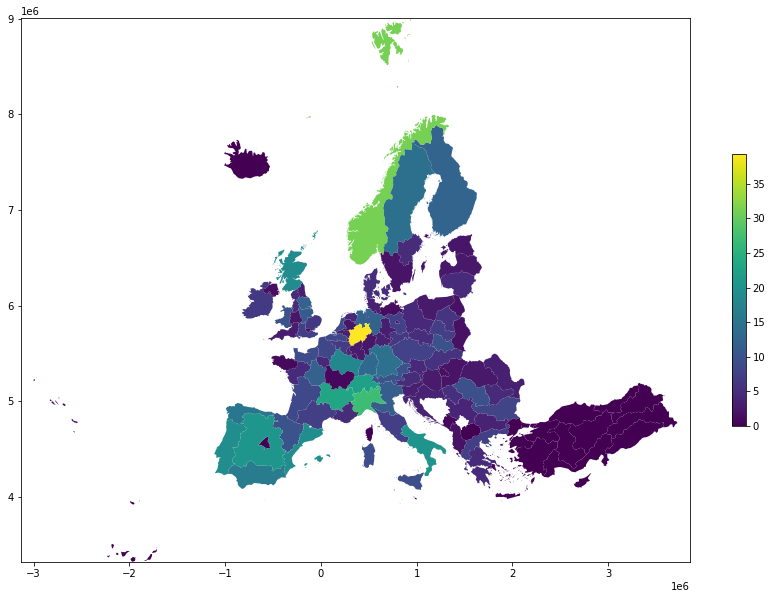

In [39]:
# Map the data

# Choose a projection: 
''''
ccrs.PlateCarree()
ccrs.Mollweide()
ccrs.EqualEarth()
ccrs.AlbersEqualArea()
ccrs.Orthographic()
'''
crs = ccrs.EuroPP() #3035
NUTS1 = NUTS1.to_crs(crs)

# Focus on Europe - removing the French Territories
lonmin, latmin, lonmax, latmax = NUTS1[NUTS1['NUTS_ID']!='FRY'].total_bounds

# Plot the capacities
ax = NUTS1.plot(column='cap', 
                legend=True,
                legend_kwds={"shrink":.5},
                figsize=(15,10))
ax.axis("equal")
ax.axis([lonmin, lonmax, latmin, latmax])

In [40]:
NUTS1.sort_values('cap', ascending=False).head(5)

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,geometry,cap
id,,,,,,,,,,,
DEA,DEA,1,DE,Nordrhein-Westfalen,Nordrhein-Westfalen,0.0,0,0,DEA,"POLYGON ((479838.658 5816864.260, 480161.852 5...",39.299370
NO0,NO0,1,NO,Norge,Norge,0.0,0,0,NO0,"MULTIPOLYGON (((937353.502 8980089.573, 930291...",31.064394
ITC,ITC,1,IT,Nord-Ovest,Nord-Ovest,0.0,0,0,ITC,"POLYGON ((642924.064 5077208.600, 627545.132 5...",26.958122
FRK,FRK,1,FR,Auvergne-Rhône-Alpes,Auvergne-Rhône-Alpes,0.0,0,0,FRK,"POLYGON ((44581.082 5199791.806, 56177.225 518...",23.091838
CH0,CH0,1,CH,Schweiz/Suisse/Svizzera,Schweiz/Suisse/Svizzera,0.0,0,0,CH0,"POLYGON ((475267.309 5281429.897, 484664.875 5...",22.399810


### It looks like Germany has the most power generation!

### Practice 6

See if you can answer some of the following questions:

1. Which country has the most nuclear power?
2. Which country has the most solar power?
3. Which country has the most wind power?

HINT - it is probably best to write a functi0n to answer the above questions (takes as an input fuel type)



In [ ]:
# Your Code Here


### Practice 7 - Challenge

Write a function that allows the user to input a country name and then the function outputs all sorts of interesting information about the power capabilities of that country: total capacity, number of each type of power,the technologies used, etc.

In [ ]:
# Your Code here

